# Credit Risk Analysis and Customer Segmentation

## Objective

Analyze banking customer data to identify financial patterns that help understand customer risk profiles and support better lending decisions.

## Business Questions

- Which customers are financially stronger?
- Which customers have higher lending risk?
- How does income affect deposits and loans?
- Which customer groups should receive premium banking services?

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [13]:
df=pd.read_csv("Banking.csv") 
df.head()

,Client ID,Name,Age,Location ID,Joined Bank,Banking Contact,Nationality,Occupation,Fee Structure,Loyalty Classification,...,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
0,IND81288,Raymond Mills,24,34324,06-05-2019,Anthony Torres,American,Safety Technician IV,High,Jade,...,1485828.64,603617.88,607332.46,12249.96,1134475.30,1,2,1,1,1
1,IND65833,Julia Spencer,23,42205,10-12-2001,Jonathan Hawkins,African,Software Consultant,High,Jade,...,641482.79,229521.37,344635.16,61162.31,2000526.10,1,3,2,1,2
2,IND47499,Stephen Murray,27,7314,25-01-2010,Anthony Berry,European,Help Desk Operator,High,Gold,...,1033401.59,652674.69,203054.35,79071.78,548137.58,1,3,3,2,3
3,IND72498,Virginia Garza,40,34594,28-03-2019,Steve Diaz,American,Geologist II,Mid,Silver,...,1048157.49,1048157.49,234685.02,57513.65,1148402.29,0,4,4,1,4
4,IND60181,Melissa Sanders,46,41269,20-07-2012,Shawn Long,American,Assistant Professor,Mid,Platinum,...,487782.53,446644.25,128351.45,30012.14,1674412.12,0,3,1,2,5


In [17]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Client ID                 3000 non-null   object 
 1   Name                      3000 non-null   object 
 2   Age                       3000 non-null   int64  
 3   Location ID               3000 non-null   int64  
 4   Joined Bank               3000 non-null   object 
 5   Banking Contact           3000 non-null   object 
 6   Nationality               3000 non-null   object 
 7   Occupation                3000 non-null   object 
 8   Fee Structure             3000 non-null   object 
 9   Loyalty Classification    3000 non-null   object 
 10  Estimated Income          3000 non-null   float64
 11  Superannuation Savings    3000 non-null   float64
 12  Amount of Credit Cards    3000 non-null   int64  
 13  Credit Card Balance       3000 non-null   float64
 14  Bank Loa

In [16]:
#generate descriptive statistics for the dataframe
df.describe()

,Age,Location ID,Estimated Income,Superannuation Savings,Amount of Credit Cards,Credit Card Balance,Bank Loans,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3000.000000,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,51.039667,21563.323000,171305.034263,25531.599673,1.463667,3176.206943,5.913862e+05,6.715602e+05,3.210929e+05,2.329084e+05,29883.529993,8.667598e+05,1.518667,2.249333,2.559333,1.504000,10.425333
std,19.854760,12462.273017,111935.808209,16259.950770,0.676387,2497.094709,4.575570e+05,6.457169e+05,2.820796e+05,2.300078e+05,23109.924010,6.412303e+05,1.102145,1.131191,1.007713,0.500067,5.988242
min,17.000000,12.000000,15919.480000,1482.030000,1.000000,1.170000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,45.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,1.000000
25%,34.000000,10803.500000,82906.595000,12513.775000,1.000000,1236.630000,2.396281e+05,2.044004e+05,1.199475e+05,7.479440e+04,11916.542500,3.748251e+05,1.000000,1.000000,2.000000,1.000000,5.000000
50%,51.000000,21129.500000,142313.480000,22357.355000,1.000000,2560.805000,4.797934e+05,4.633165e+05,2.428157e+05,1.640866e+05,24341.190000,7.113147e+05,2.000000,2.000000,3.000000,2.000000,10.000000
75%,69.000000,32054.500000,242290.305000,35464.740000,2.000000,4522.632500,8.258130e+05,9.427546e+05,4.348749e+05,3.155750e+05,41966.392500,1.185110e+06,2.000000,3.000000,3.000000,2.000000,15.000000
max,85.000000,43369.000000,522330.260000,75963.900000,3.000000,13991.990000,2.667557e+06,3.890598e+06,1.969923e+06,1.724118e+06,124704.870000,3.825962e+06,3.000000,5.000000,4.000000,2.000000,22.000000


In [20]:
bins=[0,100000,300000,float('inf')]
labels=['Low','Mid','High']
df['Income Band']=pd.cut(df['Estimated Income'],bins=bins,labels=labels,right=False)

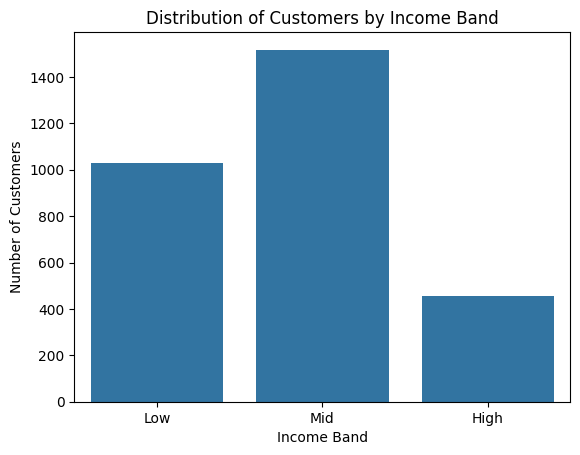

In [ ]:

sns.countplot(data=df, x='Income Band', order=['Low', 'Mid', 'High'])
plt.title("Distribution of Customers by Income Band")
plt.xlabel("Income Band")
plt.ylabel("Number of Customers")
plt.show()

In [30]:
df['Gender'] = df['GenderId'].map({
    1: 'Male',
    2: 'Female'
})

Univariate Analysis

Value Counts for 'BRId':


BRId
3    1352
1     660
2     495
4     493
Name: count, dtype: int64

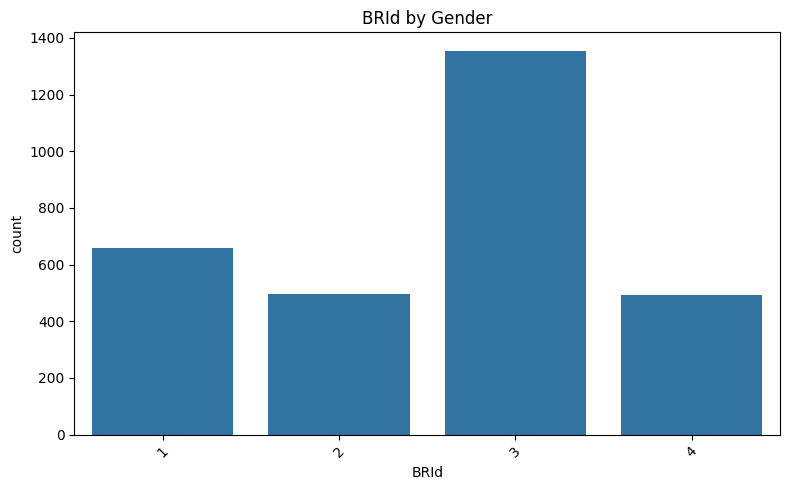

Value Counts for 'GenderId':


GenderId
2    1512
1    1488
Name: count, dtype: int64

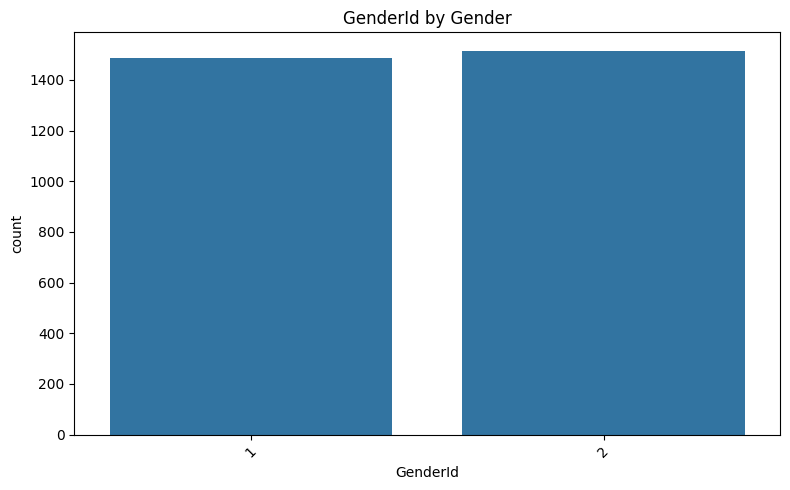

Value Counts for 'Amount of Credit Cards':


Amount of Credit Cards
1    1922
2     765
3     313
Name: count, dtype: int64

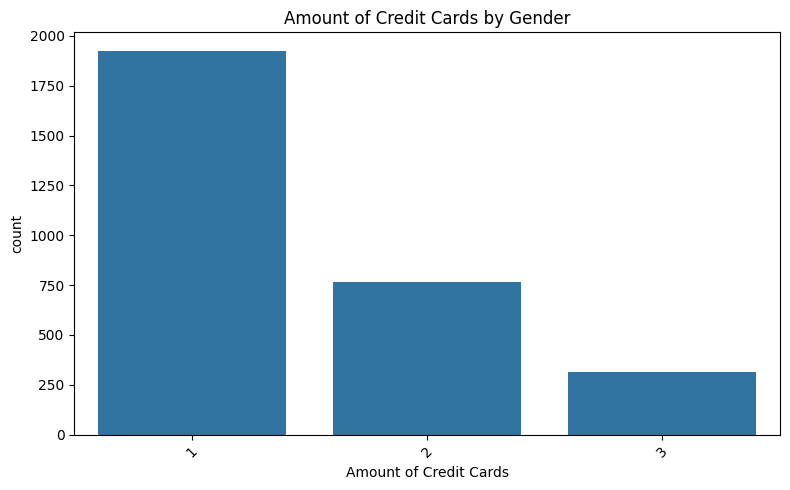

Value Counts for 'IAId':


IAId
1     177
2     177
3     177
4     177
8     177
9     176
13    176
12    176
10    176
11    176
14    176
15    176
6      89
5      89
7      89
16     88
17     88
18     88
19     88
20     88
21     88
22     88
Name: count, dtype: int64

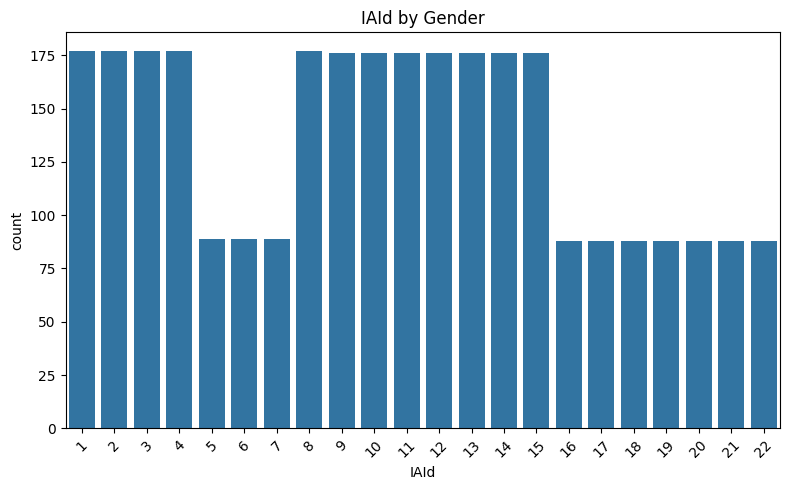

Value Counts for 'Nationality':


Nationality
European      1309
Asian          754
American       507
Australian     254
African        176
Name: count, dtype: int64

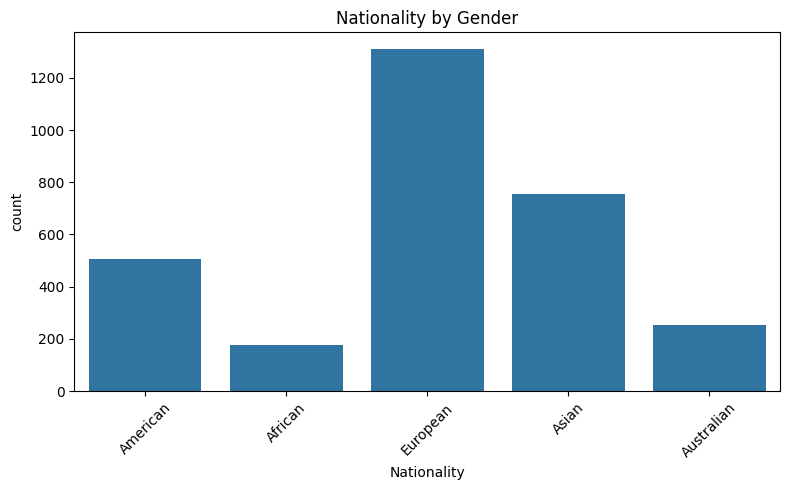

Value Counts for 'Occupation':


Occupation
Associate Professor             28
Structural Analysis Engineer    28
Recruiter                       25
Account Coordinator             24
Human Resources Manager         24
                                ..
Office Assistant IV              8
Automation Specialist I          7
Computer Systems Analyst I       6
Developer III                    5
Senior Sales Associate           4
Name: count, Length: 195, dtype: int64

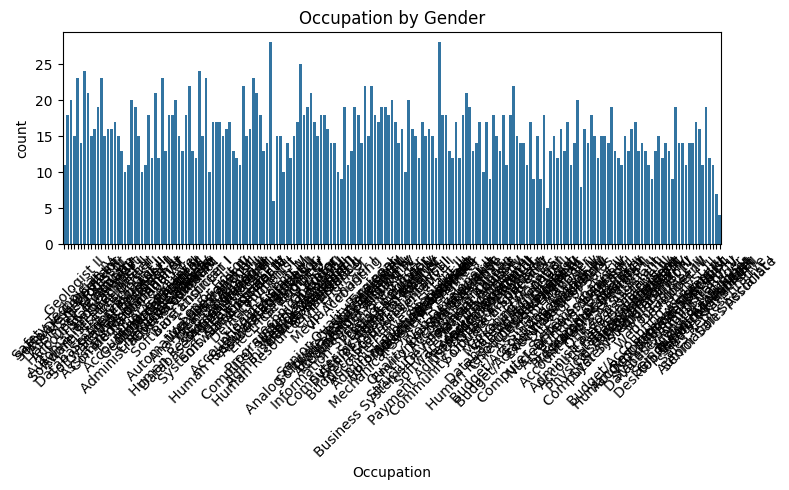

Value Counts for 'Fee Structure':


Fee Structure
High    1476
Mid      962
Low      562
Name: count, dtype: int64

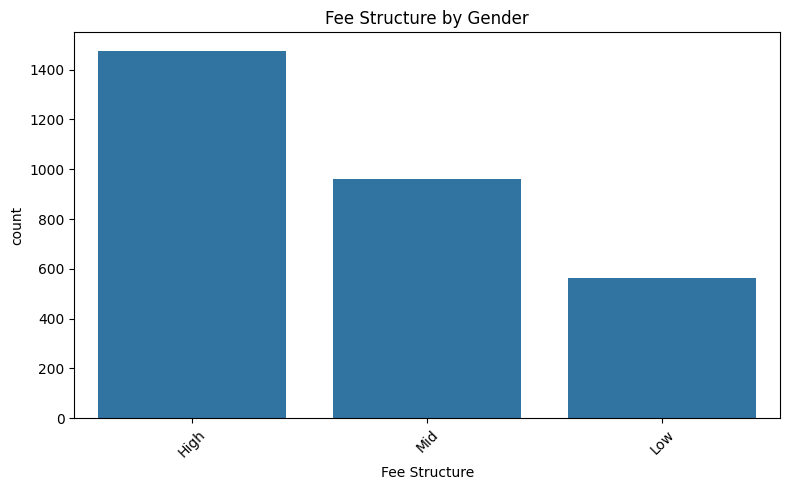

Value Counts for 'Loyalty Classification':


Loyalty Classification
Jade        1331
Silver       767
Gold         585
Platinum     317
Name: count, dtype: int64

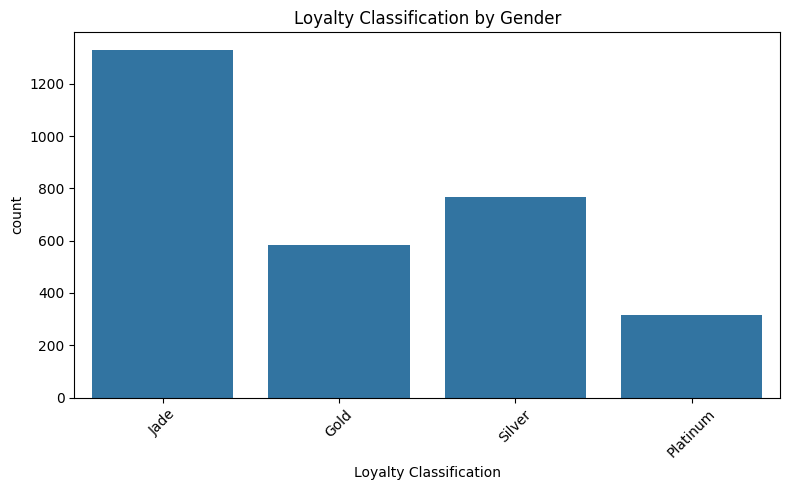

Value Counts for 'Properties Owned':


Properties Owned
2    777
1    776
3    742
0    705
Name: count, dtype: int64

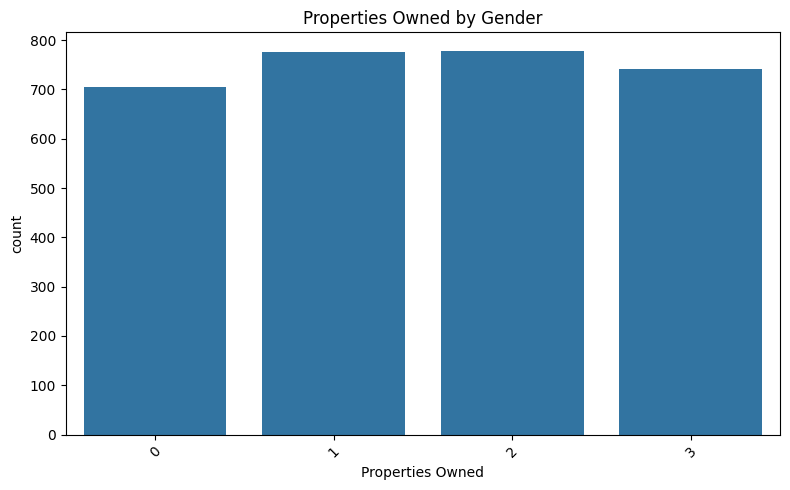

Value Counts for 'Risk Weighting':


Risk Weighting
2    1222
1     836
3     460
4     322
5     160
Name: count, dtype: int64

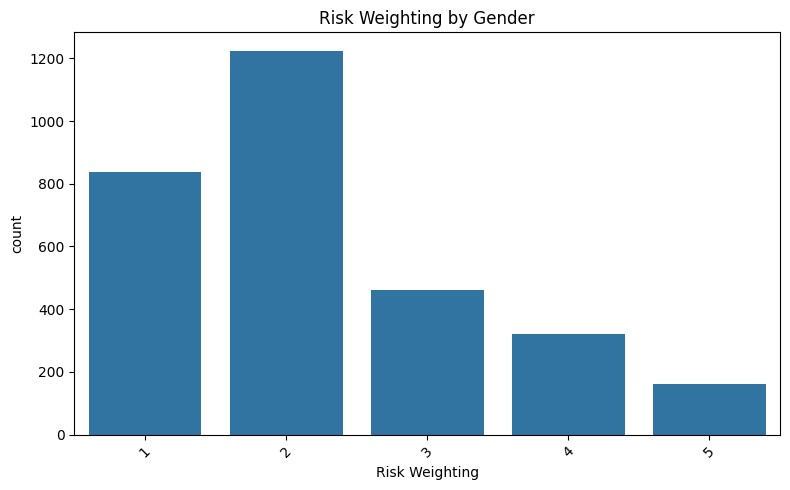

Value Counts for 'Income Band':


Income Band
Mid     1517
Low     1027
High     456
Name: count, dtype: int64

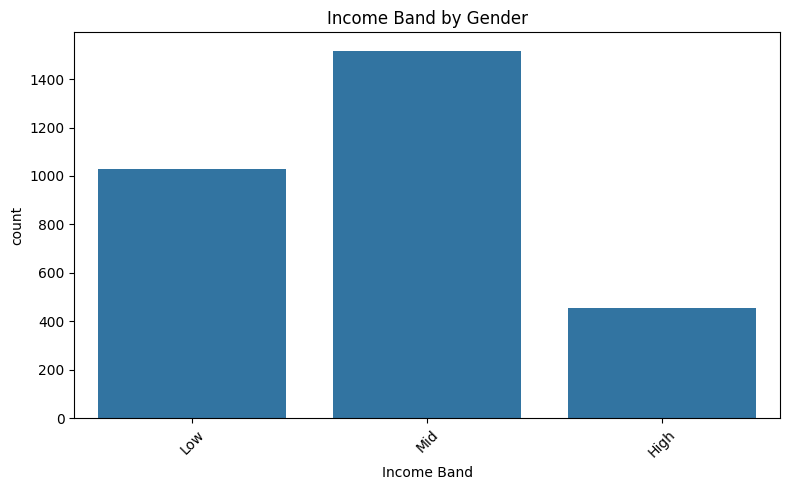

In [39]:
#examine the distribution of unique catagories in categorical columns
categorical_cols=['BRId','GenderId','Amount of Credit Cards','IAId','Nationality','Occupation','Fee Structure','Loyalty Classification','Properties Owned','Risk Weighting','Income Band']
for col in categorical_cols:
    print(f"Value Counts for '{col}':")
    display(df[col].value_counts())
    plt.figure(figsize=(8, 5))

    sns.countplot(data=df, x=col)

    plt.title(f"{col} by Gender")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Value Counts for 'BRId':


BRId
3    1352
1     660
2     495
4     493
Name: count, dtype: int64

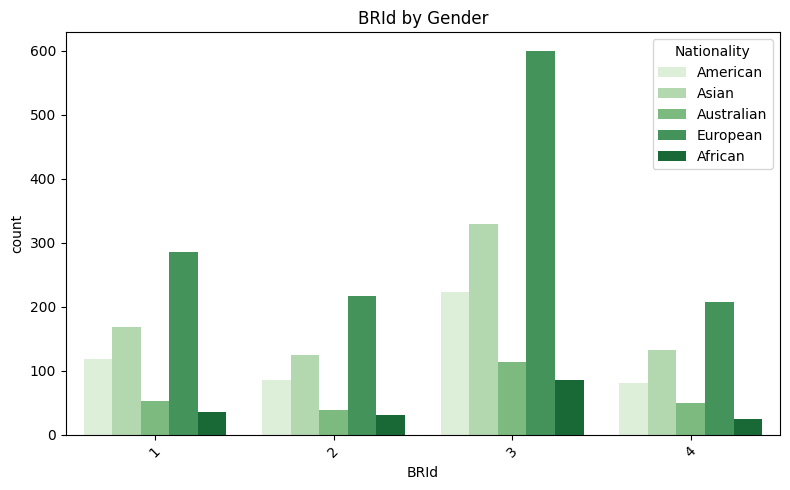

Value Counts for 'GenderId':


GenderId
2    1512
1    1488
Name: count, dtype: int64

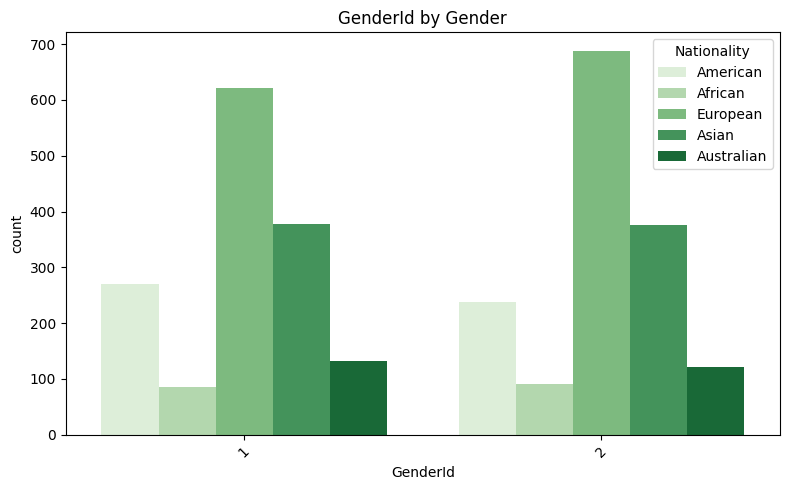

Value Counts for 'Amount of Credit Cards':


Amount of Credit Cards
1    1922
2     765
3     313
Name: count, dtype: int64

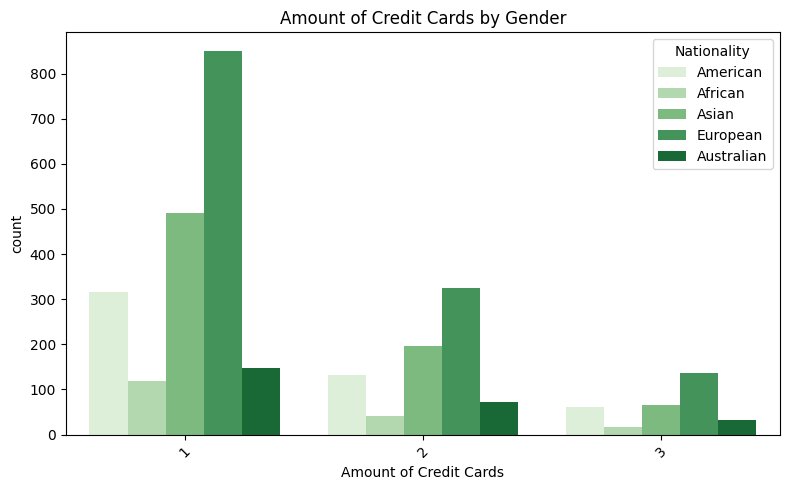

Value Counts for 'IAId':


IAId
1     177
2     177
3     177
4     177
8     177
9     176
13    176
12    176
10    176
11    176
14    176
15    176
6      89
5      89
7      89
16     88
17     88
18     88
19     88
20     88
21     88
22     88
Name: count, dtype: int64

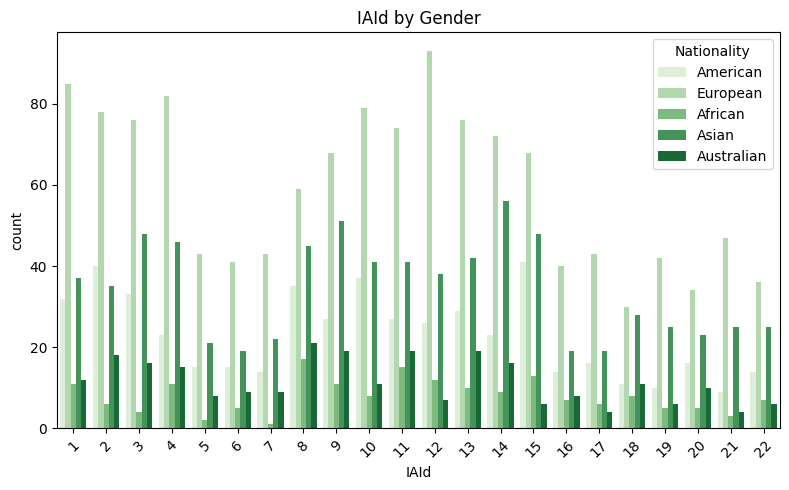

Value Counts for 'Nationality':


Nationality
European      1309
Asian          754
American       507
Australian     254
African        176
Name: count, dtype: int64

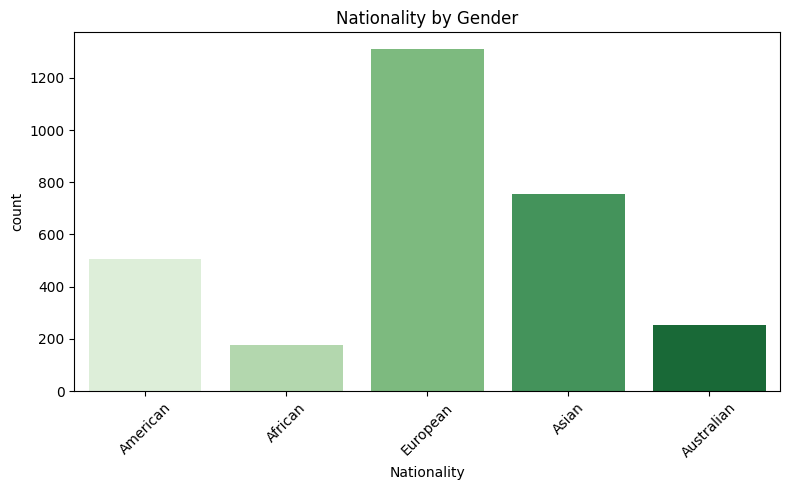

Value Counts for 'Occupation':


Occupation
Associate Professor             28
Structural Analysis Engineer    28
Recruiter                       25
Account Coordinator             24
Human Resources Manager         24
                                ..
Office Assistant IV              8
Automation Specialist I          7
Computer Systems Analyst I       6
Developer III                    5
Senior Sales Associate           4
Name: count, Length: 195, dtype: int64

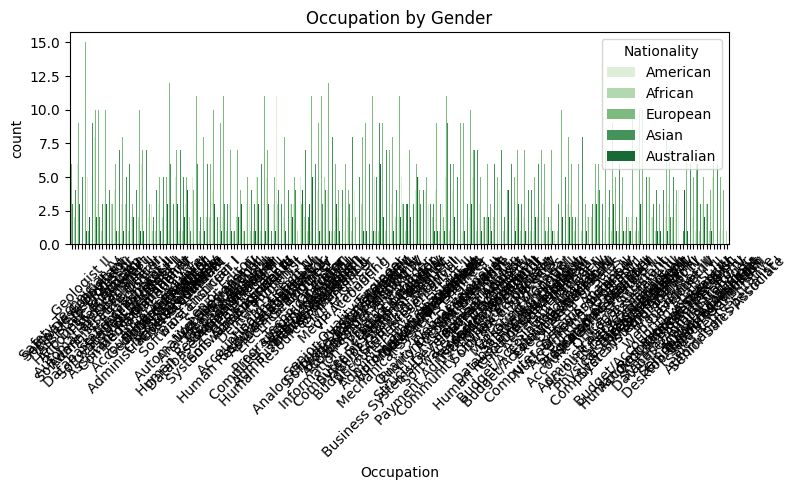

Value Counts for 'Fee Structure':


Fee Structure
High    1476
Mid      962
Low      562
Name: count, dtype: int64

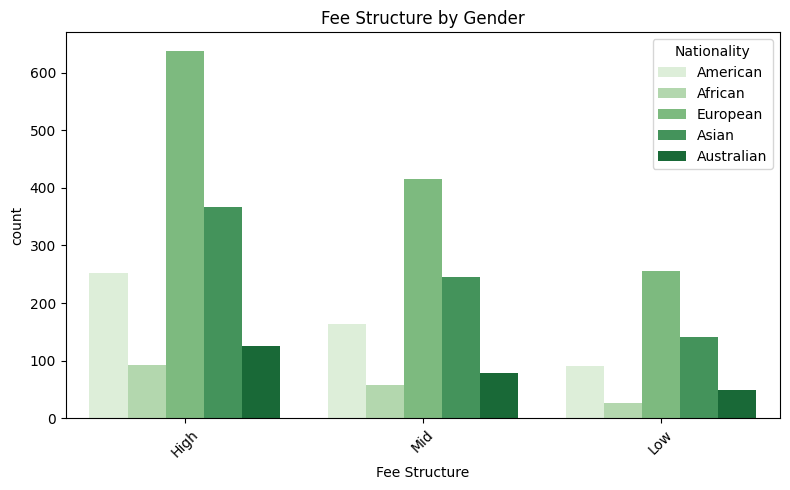

Value Counts for 'Loyalty Classification':


Loyalty Classification
Jade        1331
Silver       767
Gold         585
Platinum     317
Name: count, dtype: int64

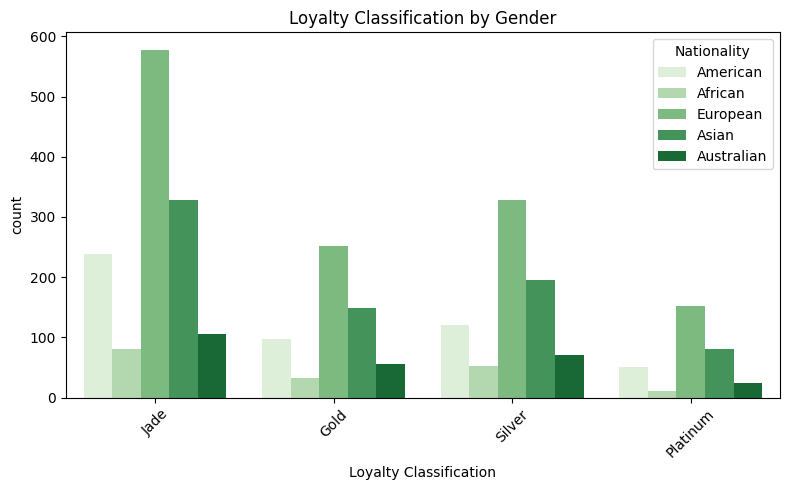

Value Counts for 'Properties Owned':


Properties Owned
2    777
1    776
3    742
0    705
Name: count, dtype: int64

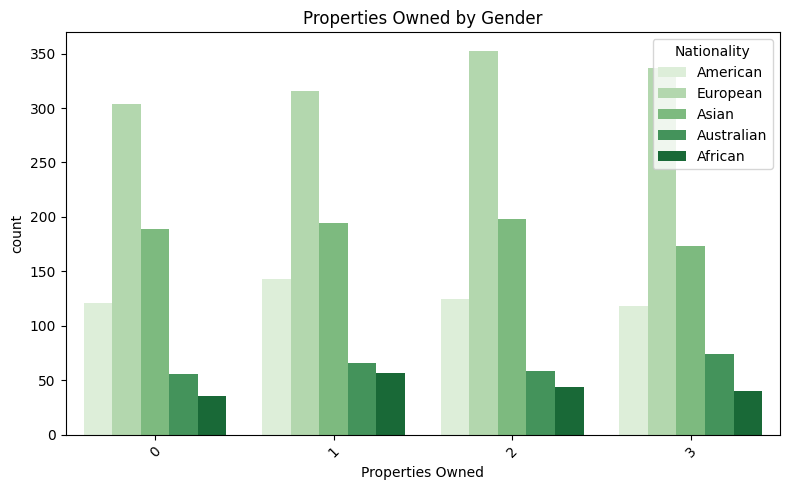

Value Counts for 'Risk Weighting':


Risk Weighting
2    1222
1     836
3     460
4     322
5     160
Name: count, dtype: int64

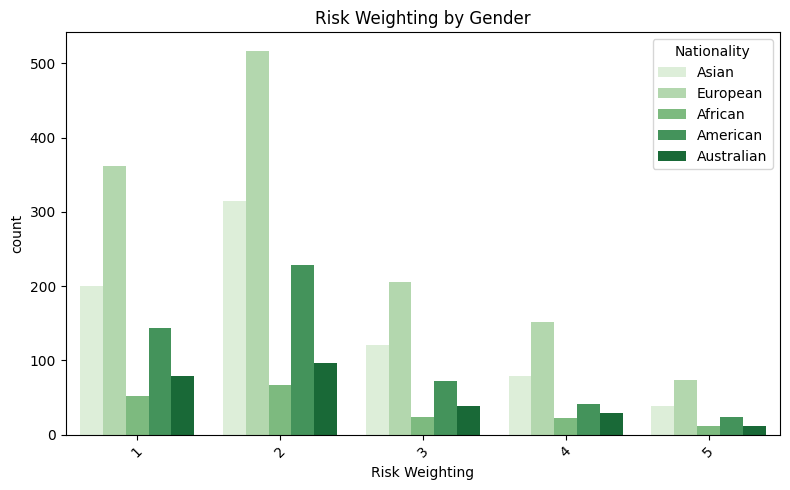

Value Counts for 'Income Band':


Income Band
Mid     1517
Low     1027
High     456
Name: count, dtype: int64

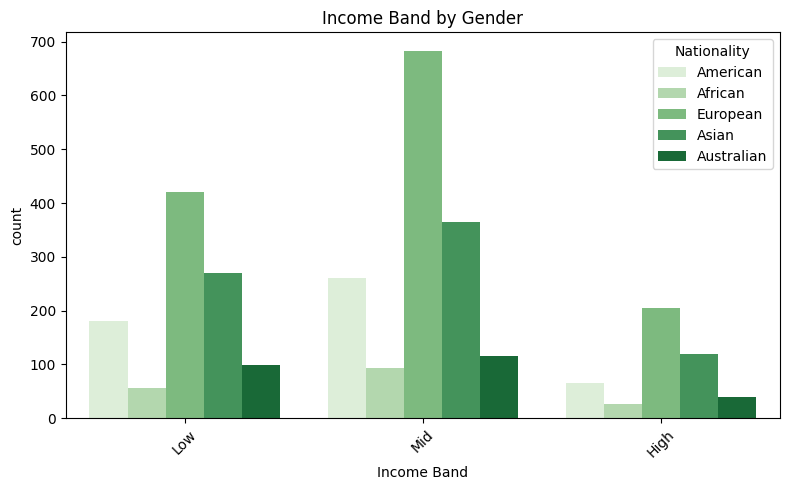

In [41]:
for col in categorical_cols:
    print(f"Value Counts for '{col}':")
    display(df[col].value_counts())
    plt.figure(figsize=(8, 5))

    sns.countplot(data=df, x=col,hue='Nationality',palette='Greens')

    plt.title(f"{col} by Gender")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

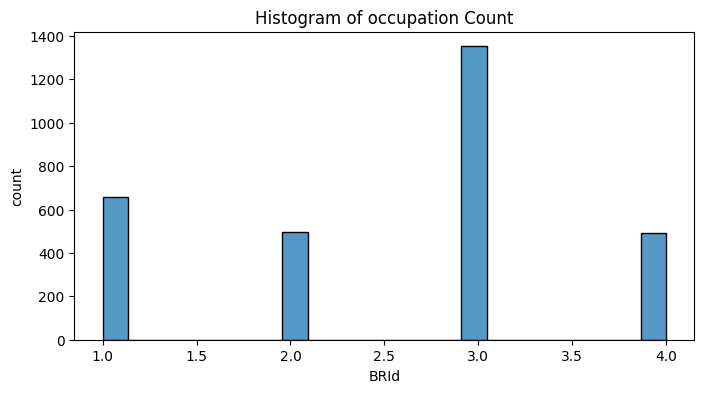

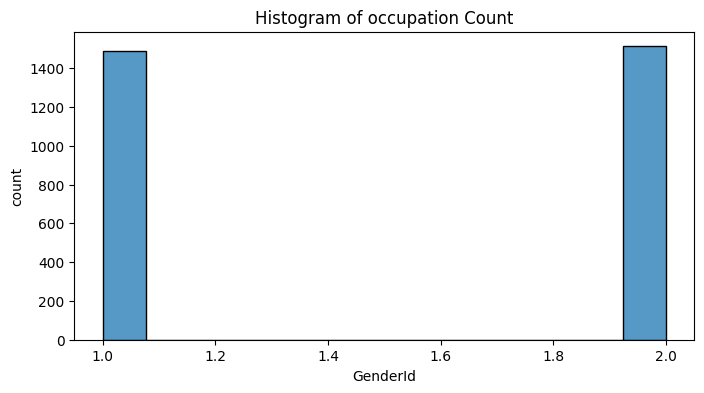

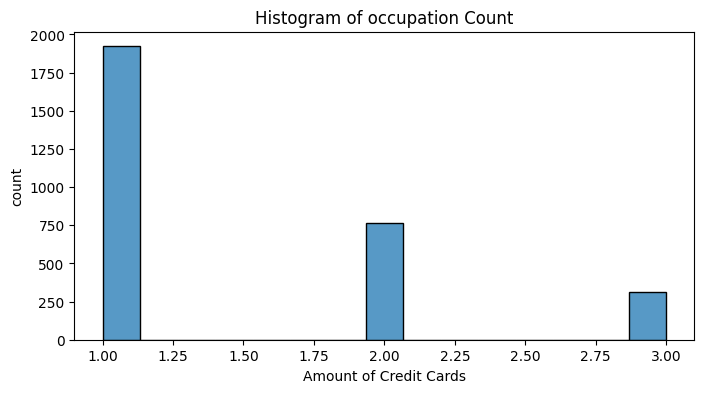

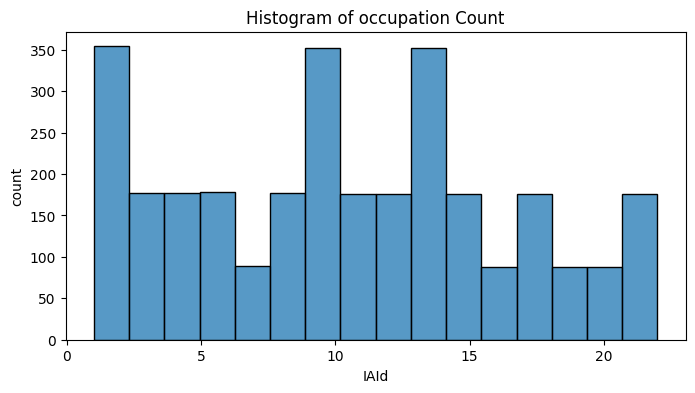

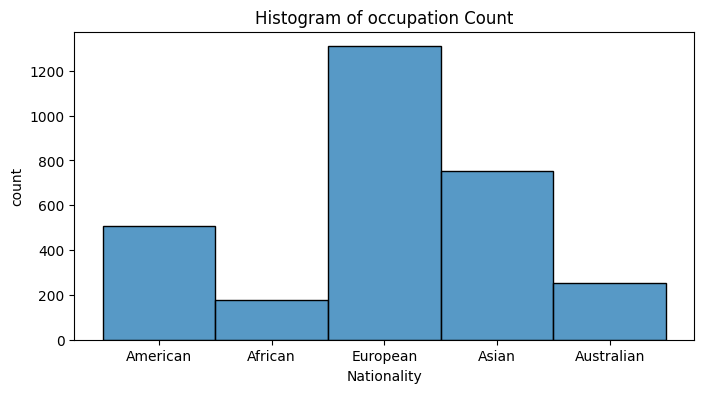

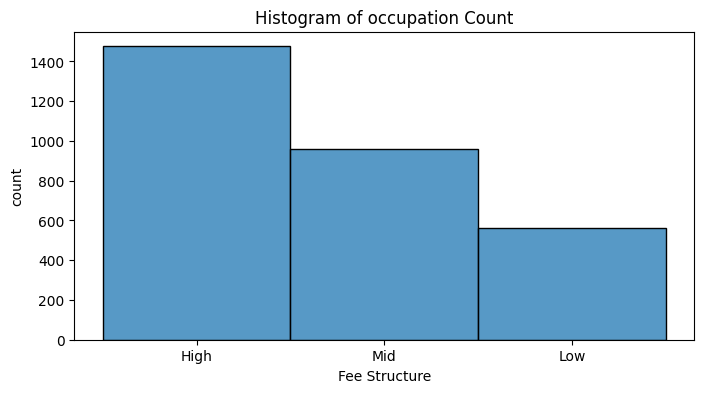

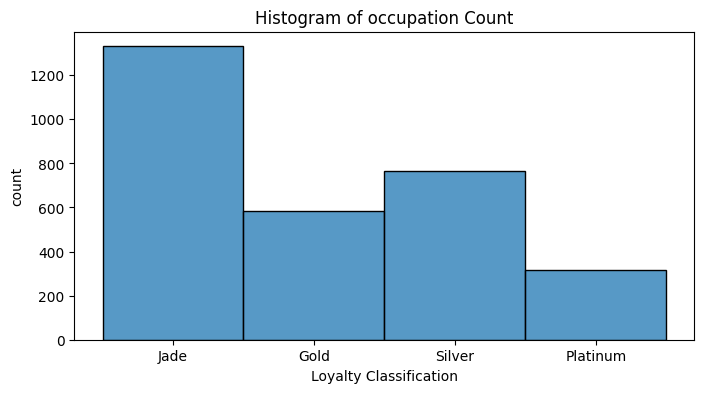

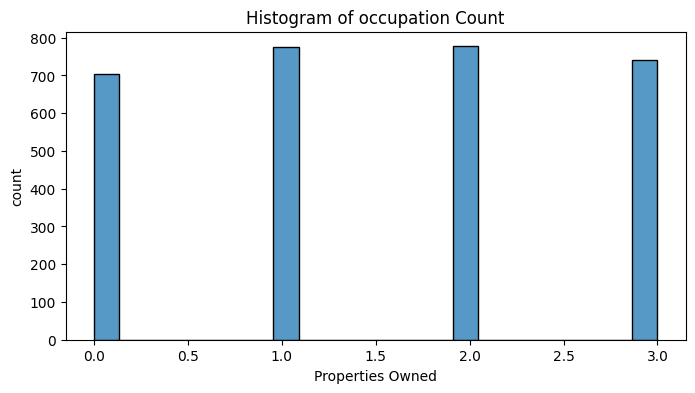

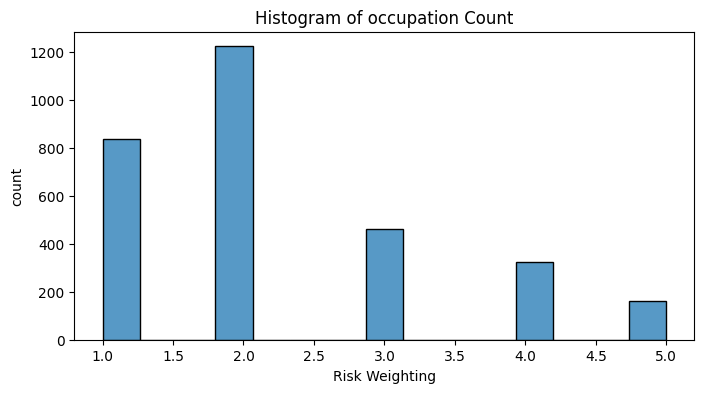

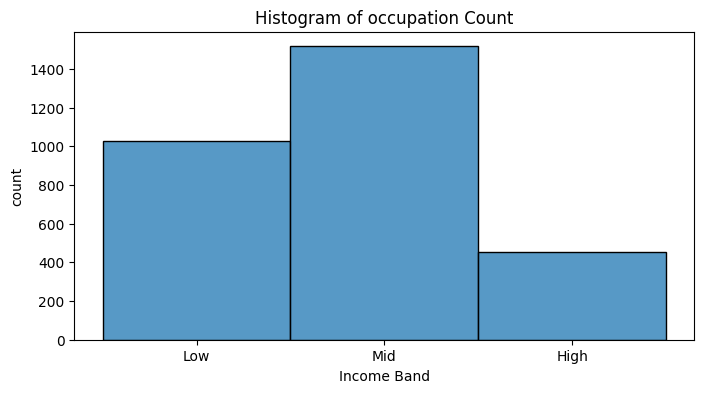

In [43]:
#Hist plot for value counts for different occupation
for col in categorical_cols:
    if col=="Occupation":  
        continue
    plt.figure(figsize=(8,4))
    sns.histplot(df[col])
    plt.title('Histogram of occupation Count')
    plt.xlabel(col)
    plt.ylabel('count')
    plt.show()

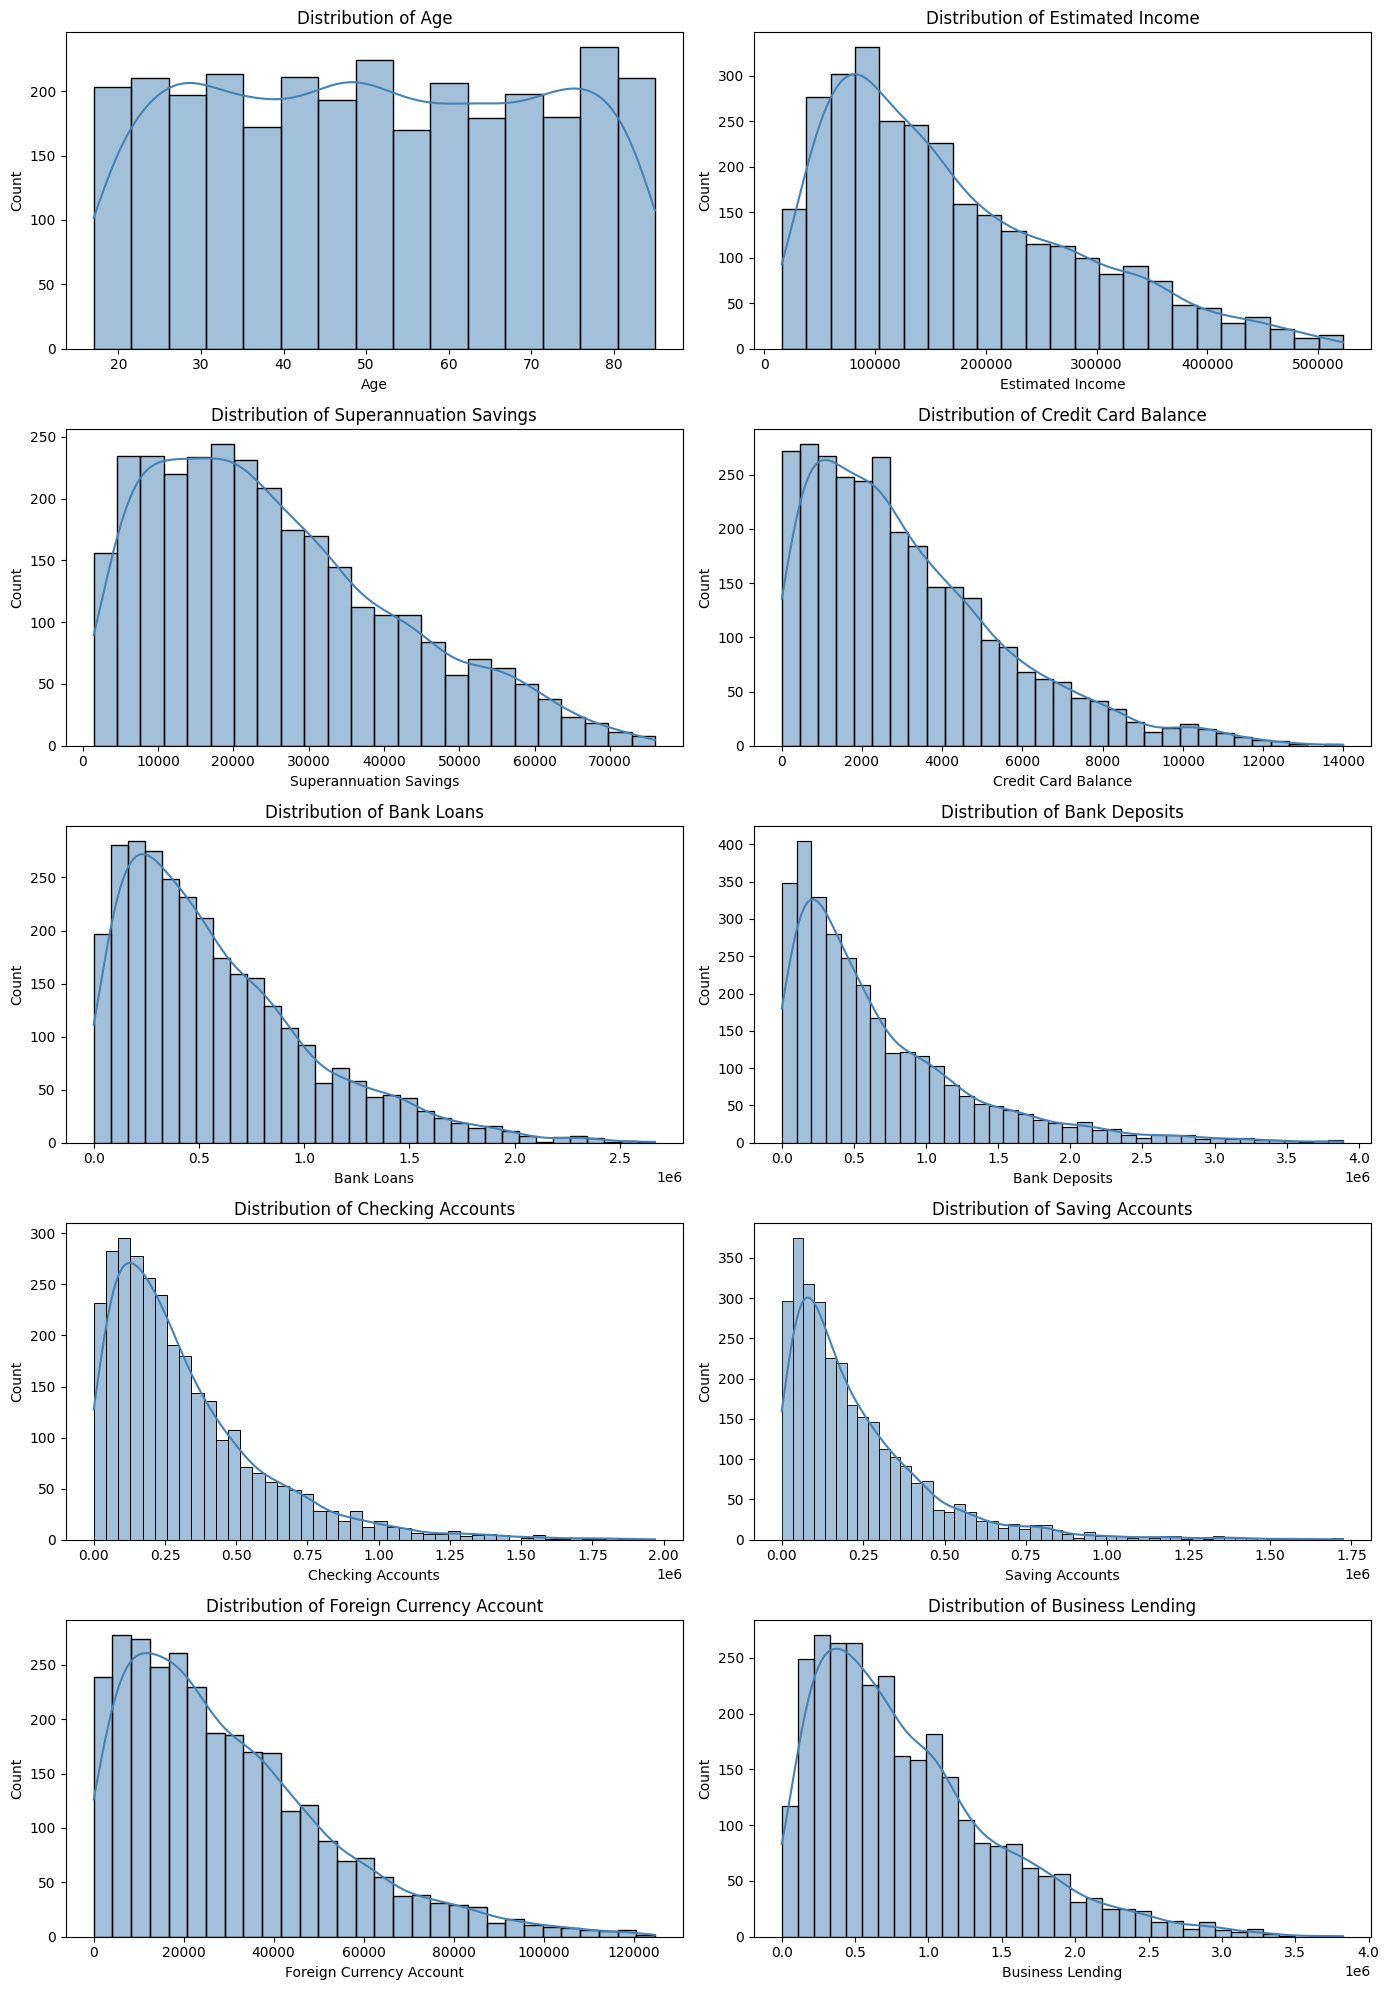

In [48]:
#Numerical analysis
numerical_cols = [
    'Age',
    'Estimated Income',
    'Superannuation Savings',
    'Credit Card Balance',
    'Bank Loans',
    'Bank Deposits',
    'Checking Accounts',
    'Saving Accounts',
    'Foreign Currency Account',
    'Business Lending'
]
#Univariate Analysis and Visualization
plt.figure(figsize=(14, 20))

for i, col in enumerate(numerical_cols):
    plt.subplot(5, 2, i + 1)
    sns.histplot(df[col], kde=True, color='steelblue')
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

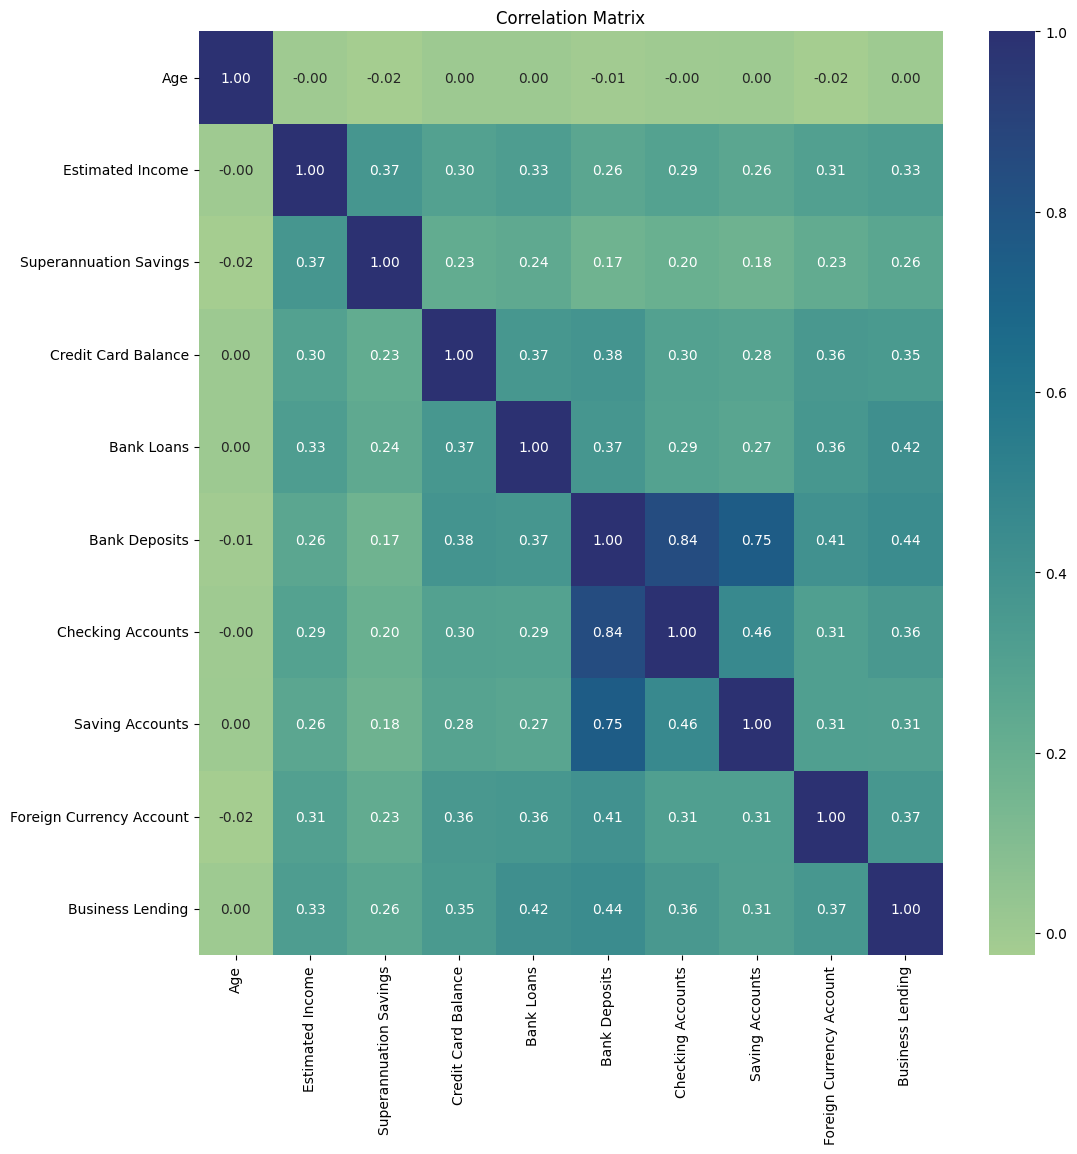

In [49]:
correlation_matrix =df[numerical_cols].corr()
plt.figure(figsize=(12,12))
sns.heatmap(correlation_matrix,annot=True,cmap='crest',fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

C:\Users\Ankita Pual\AppData\Local\Temp\ipykernel_19656\4081367733.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


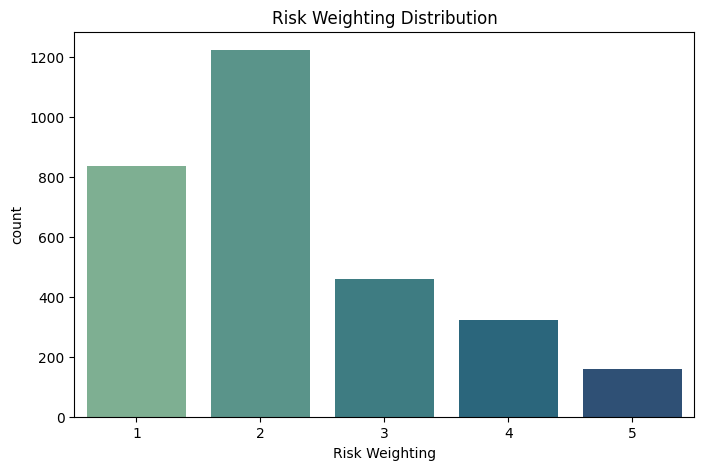

In [52]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Risk Weighting',
    palette='crest'
)

plt.title("Risk Weighting Distribution")
plt.show()

<Axes: xlabel='Income Band', ylabel='count'>

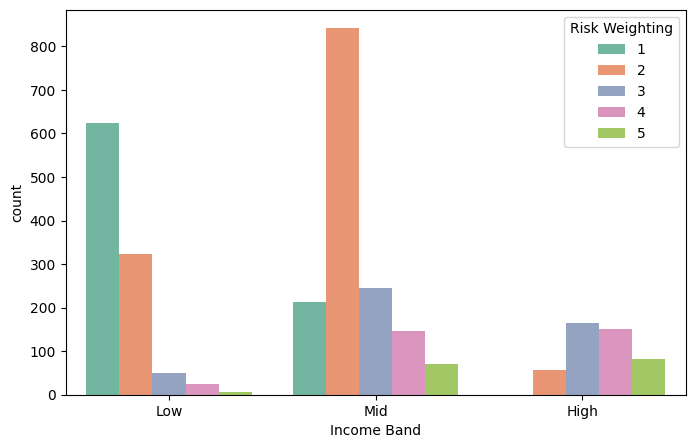

In [53]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Income Band',
    hue='Risk Weighting',
    palette='Set2'
)

<Axes: xlabel='Gender', ylabel='count'>

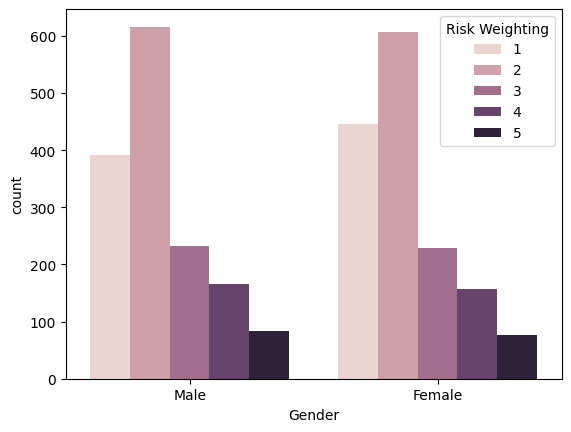

In [54]:
sns.countplot(
    data=df,
    x='Gender',
    hue='Risk Weighting'
)


<Axes: xlabel='Properties Owned', ylabel='count'>

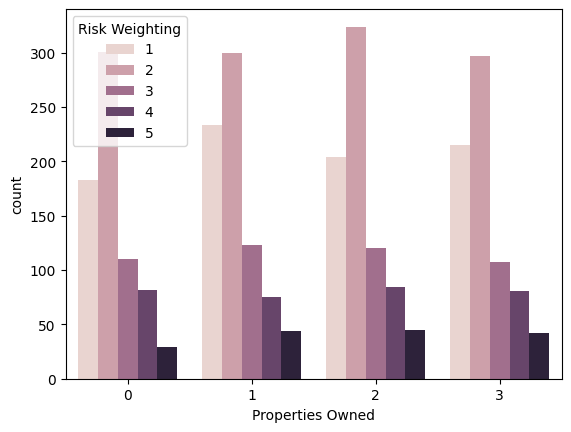

In [55]:
sns.countplot(
    data=df,
    x='Properties Owned',
    hue='Risk Weighting'
)


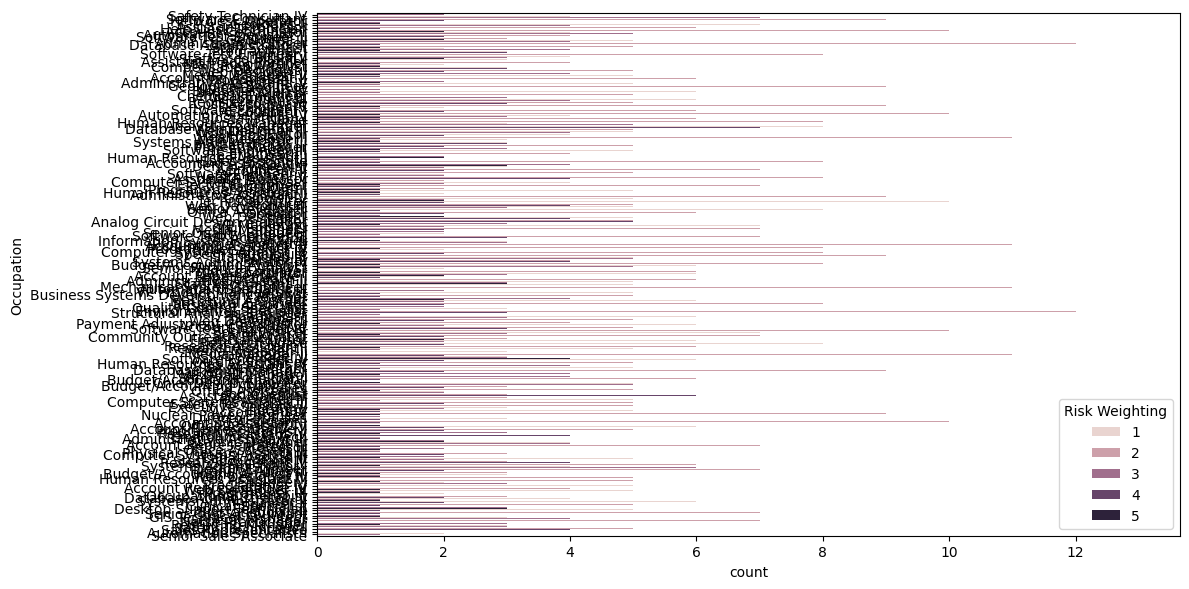

In [56]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y='Occupation',
    hue='Risk Weighting'
)

plt.tight_layout()


<Axes: xlabel='count', ylabel='Nationality'>

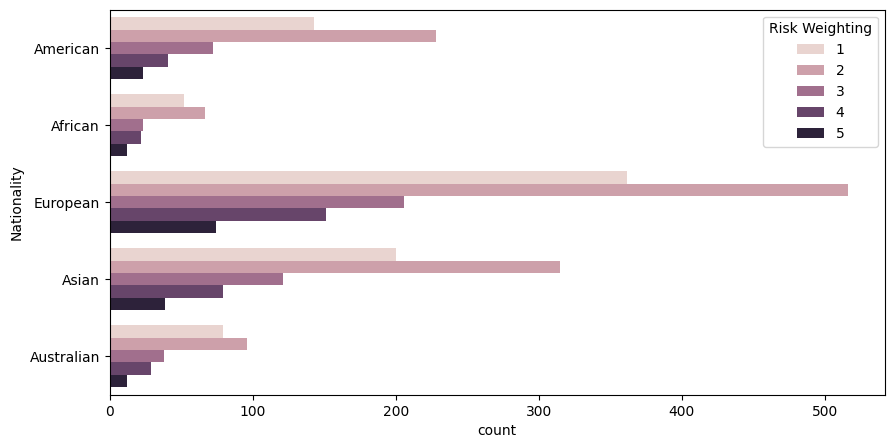

In [57]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    y='Nationality',
    hue='Risk Weighting'
)

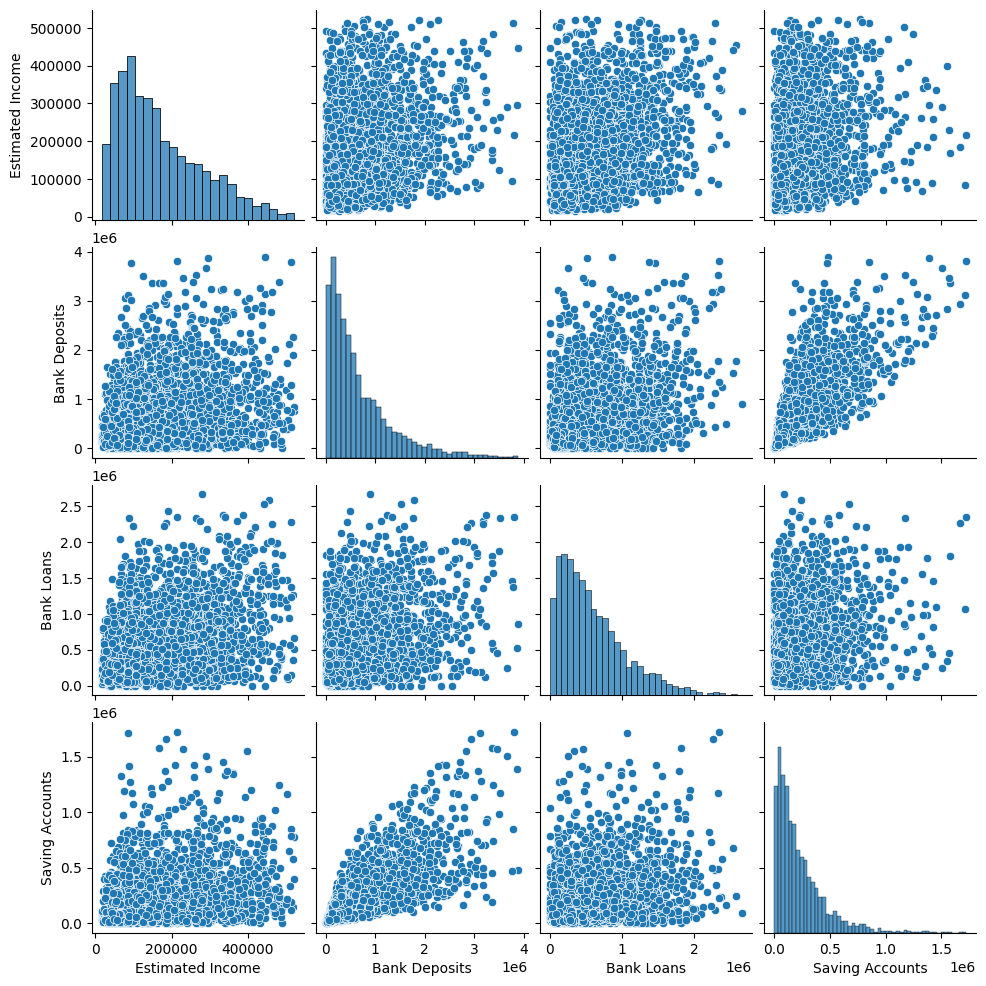

In [62]:
sns.pairplot(

df[
[
'Estimated Income',
'Bank Deposits',
'Bank Loans',
'Saving Accounts'
]

])

<Axes: xlabel='Estimated Income', ylabel='Bank Loans'>

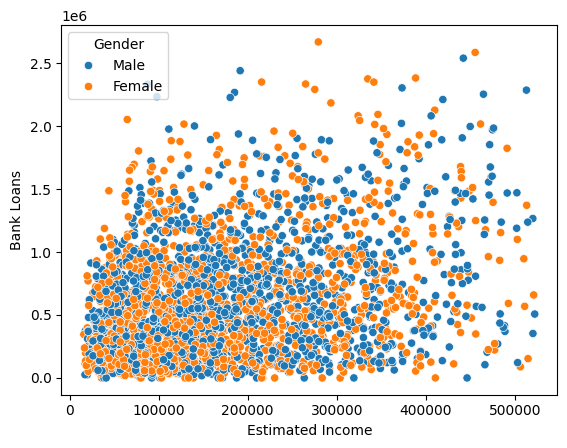

In [63]:
sns.scatterplot(

data=df,

x='Estimated Income',

y='Bank Loans',

hue='Gender'
)

<Axes: xlabel='Customer Segment', ylabel='count'>

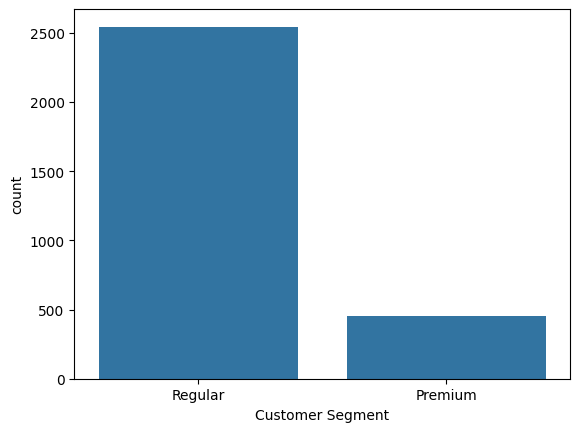

In [65]:
df['Customer Segment']=np.where(

df['Estimated Income']>300000,

'Premium',

'Regular'

)
sns.countplot(

data=df,

x='Customer Segment'
)

<Axes: xlabel='Customer Segment', ylabel='count'>

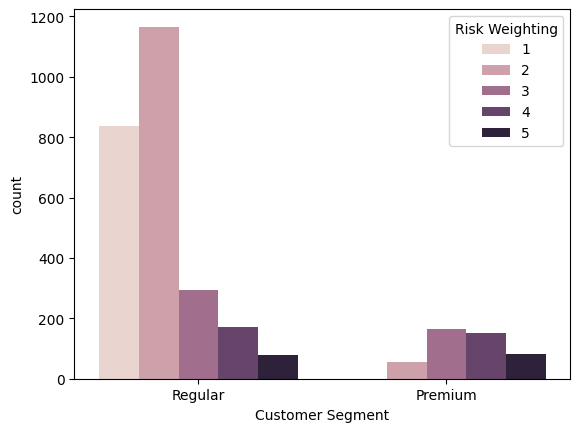

In [66]:
sns.countplot(

data=df,

x='Customer Segment',

hue='Risk Weighting'
)

In [67]:
corr=df.corr(numeric_only=True)

corr['Risk Weighting'].sort_values()

GenderId                   -0.030648
Amount of Credit Cards     -0.027378
IAId                       -0.002666
Age                        -0.001198
Properties Owned            0.003487
Location ID                 0.007579
BRId                        0.010712
Bank Deposits               0.345412
Saving Accounts             0.347358
Checking Accounts           0.373076
Credit Card Balance         0.399694
Foreign Currency Account    0.401872
Business Lending            0.417875
Bank Loans                  0.421824
Superannuation Savings      0.499640
Estimated Income            0.664726
Risk Weighting              1.000000
Name: Risk Weighting, dtype: float64

# Key Findings

# Key Findings

1. The majority of customers belong to the middle-income segment, indicating that the bank primarily serves customers with moderate earning capacity.

2. The income distribution is positively skewed, with only a small proportion of customers falling into the high-income category.

3. Bank Deposits have the strongest positive correlation with Checking Accounts (0.84) and Saving Accounts (0.75), suggesting that customers maintaining higher deposits also maintain larger account balances.

4. Age has negligible correlation with most financial variables, indicating that customer financial behaviour is influenced more by financial characteristics than age.

5. Most financial variables exhibit weak to moderate positive relationships, suggesting that multiple factors collectively influence customer financial profiles.

6. Customers with higher estimated incomes generally maintain larger retirement savings, deposits, and business lending amounts.

7. Risk Weighting category **2** contains the highest number of customers, while only a small percentage belong to the highest risk category (5), indicating that the customer base is predominantly low to moderate risk.

8. Property ownership, income, deposits, and savings can be valuable indicators when assessing a customer's overall financial strength and lending profile.

9. Customers with high deposits and multiple banking products represent strong candidates for premium banking services and personalized financial offerings.

10. The analysis highlights opportunities for customer segmentation, targeted cross-selling, and data-driven credit risk assessment to support better lending decisions.
# Recommendations

# Business Recommendations

1. Prioritize loan approvals for customers with strong financial profiles, including higher income, stable deposits, and healthy savings balances.

2. Perform additional credit assessment for customers with high existing loan amounts or large outstanding credit card balances.

3. Offer premium banking and wealth management services to customers with high deposits and higher estimated incomes.

4. Develop personalized loan and investment products based on customer income bands and financial behaviour.

5. Use Risk Weighting along with customer income, deposits, and property ownership as important factors during credit risk evaluation.

6. Strengthen cross-selling strategies by targeting customers who already maintain multiple banking products such as checking accounts, savings accounts, and business lending.

7. Monitor customers in higher risk categories regularly and provide financial advisory services to reduce potential credit defaults.